# 4 -- Grafos Dinámicos Temporales T-GNN — Dataset FDIC RIS

El problema que tratamos tiene dos dimensiones de dependencia que un modelo tabular no puede capturar. 

1. Una dependencia temporal, donde el estado de un banco en un trimestre `t` depende de su historia. Esto lo captura `TabPFN` parcialmente con la ventana deslizante, durante el entrenamiento y la evaluación y el `LSTM baseline` explícitamente.

2. Una dependencia relacional: el estado de un banco en un trimestre `t` depende del estado de sus vecinos en la red financiera. Un banco sano conectado a un _holding_ en dificultades tiene un perfil de riesgo distinto a un banco sano aislado, aunque sus ratios __CAMELS__ sean idénticos. Esto no lo captura ningún modelo tabular por construcción, ya que como vemos no tienen acceso a la estructura del grafo, que vienen dada en las bases de datos de `STRU` y `MERG`.

Una de nuestras hipotesis, y por la cual empleamos T-GCN en el TFM, es que el riesgo bancario tiene una componente sistémica no capturada por _features_ individuales, y que esa componente es observable en la estructura de relaciones entre entidades.


Primero empezemos definiendo que es un grafo estático.

> __Definición__:  Un grafo estatico, denotado como $G = (V, E)$ donde $V$ es el conjunto de nodos y $E\subseteq V × V$ el conjunto de aristas. es una estructura matemática que representa relaciones entre elementos, en la que el conjunto de vértices y el conjunto de aristas permanecen fijos durante el análisis.

El primer paso para utilizar la estructura de grafo en el contexto del ML es encontrar una representación que sea compatible con un modelo computaciónal. La elección más común es emplear una matriz de caracteristicas de nodos $X\in\mathbb{R}^{|V|\times d}$, ya que contiene la información relativa a todos los atributos de los nodos de un grafo, además cada fila representa el _embedding_ o vector de atributos de un nodo. Como vemos un grafo no solo está definido unicamente por los nodos, sino también por las relaciones entre estos nodos. La forma más simple de representar estas conexiónes es mediante la matriz de adyacencia $A\in \mathbb{R}^{|V| \times |V|}$

El problema o la limitación de los grafos estaticos es que los vértices y las aristas no cambian con el tiempo y por tanto la estructura del grafo se considera invariable durante el estudio del problema. En nuestro caso de estudio necesitamos que tanto los vertices como las aristas varien según los datos temporales que tenemos, luego necesitamos un grafo dinamico o temporal, donde los nodos y las conexiones entre ellos pueden aparecer, desaparecer o modificarse con el tiempo.

> __Definición:__ Un grafo dinámico es un modelo de grafo cuya estructura evoluciona a lo largo del tiempo. En lugar de considerar un único conjunto fijo de nodos y aristas, el sistema se representa mediante una secuencia temporal de snapshots o grafos estáticos:
>
> $$
> G = \{G^1, G^2, \dots, G^T\}
> $$
>
> donde cada snapshot $G^t$, para $t \in \{1,\dots,T\}$, se define como
>
> $$
> G^t = (V^t, E^t, X^t, A^t)
> $$
>
> siendo:
>
> - $V^t$ el conjunto de vértices presentes en el instante $t$,
> - $E^t$ el conjunto de aristas presentes en el instante $t$,
> - $X^t$ la matriz de características de nodo en el instante $t$, donde cada nodo puede poseer atributos o variables descriptivas,
> - $A^t$ la matriz de adyacencia asociada al grafo en el instante $t$, definida por
>
> $$
> A_{ij}^t =
> \begin{cases}
> 1 & \text{si existe una arista entre } i \text{ y } j \text{ en } t, \\
> 0 & \text{en caso contrario.}
> \end{cases}
> $$
>
> para el caso de grafos no ponderados.

Un problema que tenemos con la matriz de adyacencia es que posee un alto coste de almacenamiento en función del orden del conjunto de nodos, del orden de $\mathcal{O}(|n|^2)$. Otro problema uqe presenta es que al poder permutar el orden de los nodos en la matriz no se puede asegurar que dos matrices diferentes produzcan el mismo resultado en un modelo de ML, incluso si representan los mismos datos.

> __Definición (Invariancia a permutaciones):__ Sea $V$ un conjunto, consideremos el conjunto $\mathbb{G}$ de todos los grafos con conjuntos de vertices $V$ tales que los pesos de los vertices y    > aristas tienen dimensión $n$ y $m$. Una aplicación $f:\mathbb{G} \to \mathbb{G}$ es invariante a permutaciones si para cualquier permutación $\pi$ de $V$ se cumple:
>$$
>f(\mathbb{G})=f(\pi\mathbb{G})=f(V, \{\pi e~|~e\in E\}, \pi w_V, \pi w_E)
>$$
>donde $\pi\mathbb{G}$ es el grafo resultante de aplicar $\pi$ a los vertices del grafo $G$
>$$
>\pi w_V=w_V\bullet\pi^{-1}, \pi w_E=w_E\bullet\pi^{-1}
>$$

El problema de la invarianza se solucióna meidante la modificación de redes neuronales utilizadas para garantizar el procesamiento consistente de los grafos, independientemente del orden o etiquetado de los nodos. La forma de asegurar la invarianza a paermutaciónes de la salida de una NN para dos matrices adyacentes con distinto orden de nodos, auque representen el mismo grafo, mendiante la construcción de una arquitectura de _Graph Neural Network (GNN)_. Estas redes reciben como entrada un grafo con información cargada en sus nodos y aristas y transforma progresibamente estos datos sin cambiar la conectividad del grafo.


> __Definición (función simetrica)__: Una función $f:X^n\to Y$ es simetrica si es invariante a permutaciones, es decir, si:
>$$
>f(X_1,\dots X_n) = f(X_{\pi(1)},\dots, X_{\pi(n)}) ~~~~ \forall \pi ~~\text{de}~~ \{1,\dots,n\}
>$$

> __Definición (función de agregación)__: Sea $G = (V, E)$ un grafo donde cada nodo $v_i\in V$ tiene asignado un embedding $h_i\in\mathbb{R}^m$. Una función de agregación para el nodo $v_i$ es una aplicación de la forma:
>$$
>f:(\mathbb{R}^m)^{n_i}\to\mathbb{R}^m
>$$
>donde $n_i=\mathcal{N}(i)$, es decir, se toman los atributos de los nodos vecinos de $v_i$ y produce un resumen.

Las _Graph Neural Networks (GNNs)_ constituyen el paradigma fundamental para el aprendizaje sobre datos estructurados en forma de grafo. Una definición formal de estos modelos es:

> __Definición (GNN)__: Una _Graph Neural Networks_ es una transformación invariante a permutaciónes del orden de los datos de entrada que toma como entrada un grafo $G=(V, E)$, donde cada nodo tiene asignado un embedding $h_i\in\mathbb{R}^m$. La transformación actualiza los atributos de los nodos $h_i^{(k)}$ en cada capa $k$ utilizando caracteristicas de los nodos vecinos para obtener información del resto del grafo. La capa $k$ se define como
>$$
>h_i^{(k+1)}=f^{(k)}\Big(h_{j1}^{(k)},\dots,h_{jn_i}^{(k)} \Big)
>$$
>donde $v_{jl}\in\mathcal{N}(i)$ para $l=1,\dots,n_i$ y $f^{(k)}$ es una función simetrica de agragación y actualización. Dada la matriz de caracteristicas de nodos $X^0$ que contiene todos los >_embeddings_ iniciales del grafo, podemos definir la salida de una red de $L$ capas como
>$$
>Y = f^{(L)}(f^{(L-1)}(\dots f^{(1)}(X^0)))
>$$

La salida de la _GNN_ es un grafo $G^´ = (V, E)$ con los mismos nodos y aristas que el grafo de entrada pero con sus atributos modificados.

> __Proposición__ La salida de una GNN es invariante al orden de los valores de entrada.

Para realizar predicciónes más elaboradas, una formulación unificadora se basa en el esquema de _Message Passing Neural Networks (MPNN)_ propuesto por Gilmer et al. (2017), donde se aplican tecnicas de agrupamiento de la información en las capas de una _GNN_, consiguiendo uqe los nuevos _embeddings_ obtenidos tras aplicar cada capa dependan de la conectividad del grafo más alla de los nodos adyacentes. Este agrupamiento se consigue haciendo que los nodos o aristas adyacentes intercambien información en cada capa de la red, influyendo asi en el resto de los atributos del grafo.

En este marco, la transmisión se divide en tres pasos:

1. __Recolección__: Para cada nodo $v$ en el grafo $G$ se recopilan los embeddings de todos los nodos $u\in\mathcal{N}(v)$, los nodos adyacentes a $v$. El reusltado es una simple concatenación de los embeddings de las aristas
$$
H_v = [h_{u_1}, h_{u_2},\dots, h_{u_{di}}]
$$
donde $d_i$ es el numero de vecinos del nodo $v$.

2. __Agregación:__ Los embeddigns de estos nodos, denotados como $h_u$ se combinan mediante una función de agregación simetrica.
$$
m_v^{(l)} = \text{AGGREGATE}\left(\{h_u^{(l-1)} : u \in \mathcal{N}(v)\}\right)
$$
donde $m_v^{(l)}$ es el mensaje combinado que resume la información de todos los vecinos de $v$.

3. __Actualización:__ El mensaje agregado $m_v^{(l)}$ se transforma usando una función de actualización $f$ para obtener el nuevo embedding del nodo $v4 con los atributos actualizados
$$
h_v^{(l)} = \text{UPDATE}\left(h_v^{(l-1)}, m_v^{(l)}\right)
$$
donde $ \mathcal{N}(v) $ representa el vecindario del nodo $ v $, y $ h_v^{(l)} $ es la representación latente (embedding) del nodo en la capa $ l $. Iterando este proceso, un nodo puede incorporar información proveniente de cualquier parte del grafo, lo que aumenta la capacidad del modelo para conseguir mejores predicciónes. Podemos concatenar los tres pasos en una sola eccuación
$$
h_v^{(l+1)}=\sigma(W_1\cdot h_v^{(l)} + W_2\cdot H_v^{(l)})
$$
donde usamos como función de agregación simetrica la suma, donde $\sigma$ es una función de activación no lineal (ReLU) y $W_1, W_2$ son matrices de pesos para sumar y ponderar los atributos de los nodos vecinos y la capa anterior.


__Observación__: La transmisión de mensajes que hemos descrito ocurre solo entre nodos o entre aristas unicamente. En caso de querer mezclar información de los embeddings de nodos y aristas, tenemos que tener en cuenta ciertas consideraciónes como la dimensión entre los embeddings de los nodos y de las aristas, las cuales se deberan ajustar. Para ajustar estas dimensiones originales y adapatarlos a su nuevo significado es comun aplicar una transformación lineal desde un espacio de nodos a un espacio de aristas y viceversa. Si ya existen atributos en la arista, podemos combinarla entonces con la información proveniente de los nodos talque:
$$
h_{e_{uv}}^{(l+1)}=W_{node\to edge}\cdot h_v + W_{edge}\cdot h_{e_{uv}}
$$
donde $h_v$ es el embedding del nodo $v$, $h_{e_{uv}}$ es el embedding de la arista entre los nodos $u$ y $v$, y $W_{node\to edge}$ y $W_{edge}$ son matrices de pesos que transforman las representaciónes de nodos y aristas, respectivamente. Estos $h_{e_{uv}}^{(l+1)}$, ahora si pueden ser agregados normalmente como en el proceso anterior de _MPNN_.

Una vez descritas las _GNN_, y el _MPNN_, una de las arquitecturas que podemos diseñar mas robustas son la combinación de las GNN con las CNN. A esta nueva arquitectura la definimos como redes neuronales de grafos convoluciónales (GCN), y como veremos mas adelante son una de las partes más importantes de las T-GCN.

> __Definición:__ Las redes neuronales convoluciónales CNN son un tipo de NN que sustituyen la multiplicación de matrices de las NN tradicionales por una convolución de matrices en al menos una de sus capas. Son redes especializadas en procesar datos con estructura de cuadricula, como imagenes, aunque tambien sirven para representaciónes matriciales de grafos. En la convolución empleamos una función matricial K a modo de filtro o kernel, para extraer caracteristicas locales de los datos. La transformación $g_i$ realizada por las neuronas de la capa $i$ se definen como:
>$$
>g^{(i)}(X^{(i)})=f^{(i)}(X^{(i)}\ast K^{(i)} + b^{(i)})
>$$
>
>donde $X^{(i)}\in\mathbb{R}^{n_i}$ son los datos de entrada en la capa $i$, $K^{(i)}$ el kernel, $b^{(i)}\in\mathbb{R}^{n_i}$ un vector de sesgos (bias) y $f^{(i)}$ la función de activación de la >capa $i$ aplicada de manera componente a componente.

__OBS:__ Como hemos dicho, las GCN son redes GNN con almenos una capa de convolución, es decir, son tambien redes CNN. Se enfocan en capturar patrones locaels en los grafos con un menor coste computacional.



La adaptación de convoluciones a estructruas de grafos toma representación matriciales como la matriz de caracteristicas de nodos $X$ o las de adyacencia $A$, y se le aplican filtros polinomicos diseñados para extrar información estructural y relaciónes complejas del grafo. Existen dos tipos.

- _Filtros Espaciales:_ Trabajan directametne con la estructura del grafo $G$ y aplican convoluciónes en las vecindades $\mathcal{N}(i)$ de cada nodo $v_i\in V$ con tecnicas de agregación vistas antes en las GNN.

- _Filtros Espectrales:_ Se basan en la descomposición espectral del Laplaciano discreto matricial para explorar las propiedades globales del grafo.

El problema que tenemos es la forma de agregar la información de los vecinos de un nodo en nuestra arquitectura GCN. La opcion vista de suamr las caracteristicas de los vecinos 
$$
h_i=\sum_{j\mathcal{N}(i)}x_j
$$
falla o es ineficiente por dos razones principales. En caso de tener un nodo o nodos con un elevado numero de vecinos, hace que dicho nodo o nodos acumulen una señal mucho mayor que nodos con un solo vecino o menos vecinos, haciendo el entrenamiento inestable. Además, el nodo no incluye su propia información en la agregación. Para soluciónar estos problemas y siguiendo el marco empleado por _Kipf & Welling (2017)_ usamos el siguente filtro espectral:

> __Definición:__ Dado un grafo $G$, si $A$ es la matriz de adyacencia, $D$ la matriz diagonal de grados e $I$ la matriz identidad. El _Laplaciano normalizado_ L se define como
>$$
>L= I-D^{-1/2}AD^{-1/2}
>$$
>Dado un filtro parametrizado $g_{\theta}(\Lambda)$, el filtro espectral aplicado a unos atributos de entrada $X\in\mathbb{R}^n$ se expresa como:
>$$
>g_{\theta}(L)X = U g_{\theta}(\Lambda)U^T X
>$$
>dodne $U$ es la matriz de vectores propios (base espectral) y $\Lambda$ la matriz diagonal de valores propios obtenida de la descomposición espectral de $L$
>$$
>L = U\Lambda U^T
>$$


Por tanto, en nuestro trabajo emplearemos una GCN que emplea filtros espectrales simplificados, aproximando el laplaciano con $\hat{A} = \tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2}$, de forma que la operación realizada en la capa $K$ se define como:

$$
H^{(l+1)} = \sigma\left(\hat{A} H^{(l)} W^{(l)}\right)
$$

donde:

- $ \tilde{A} = A + I $ es la matriz de adyacencia con auto-conexiones añadidas. La auto-conexión es necesaria porque sin ella el nodo no incluye su propio estado anterior en la agregación

- $ \tilde{D} $ es la matriz diagonal de grados de $ \tilde{A} $, con $ \tilde{D}_{ii} = \sum_j \tilde{A}_{ij} $.

- $ \tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} $ es la normalización simétrica. Sin normalizar, nodos con muchos vecinos acumulan señal arbitrariamente grande. La normalización simétrica garantiza que la propagación preserve la escala de los features independientemente del grado del nodo

- $ H^{(l)} \in \mathbb{R}^{n \times d} $ representa los embeddings en la capa $ l $, con $ H^{(0)} = X $.

- $ W^{(l)} \in \mathbb{R}^{d \times d'} $ es la matriz de pesos entrenables de la capa $l$

- $ \sigma $ es una función de activación no lineal, típicamente _ReLU_.

Intuitivamente, cada capa _GCN_ permite que cada nodo agregue información de sus vecinos directos, de modo que con $ L $ capas cada nodo incorpora información de su vecindario a distancia $ L $. Esta aproximación sera la que empleemos para el entrenamiento del modelo y su evaluación.

A parte de soluciónar los problemas descritos antes, usar como kernel convoluciónal un filtro espectral, en concreto el laplaciano normalizado un la GCN, proporciona una formulación espectral del filtrado sobre grafos que es matematicametne consistente y factible computaciónalmente. El espectro nos permite interpretar la agregación vecinal como una operación de difusión suave de información, mientras que la normalización simetrica estabiliza la contribución de nodos con distintos grados y mantiene acotado el operador usado un la propagación de señales. En este contexto, el polinomio de Chebyshev desempeña un papel fundamental ya que nos permite aproximar el filtrado sobre el grafo mediante funciones polinomicas de laplacianos sin la necesiada de calcular su descomposición espectral completa, permitiendo construir convoluciones locales para simplificar las GCN.

> __Proposición:__ Sea $G=(V, E)$ un grafo simple, no dirigido y convexo, con matirz de adayacencia A. Definimos $\tilde{A} = A + I_n$ y  $ \tilde{D} $ como la matriz diagonal de grados correspondientes, $ \tilde{D} = diag(\tilde{d}_1,\dots, \tilde{d}_n) $, donde $ \tilde{D}_{i} = \sum_j \tilde{A}_{ij} $. Entonces la matriz de propagación 
>$$
>\hat{A} = \tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} = \tilde{D}^{-1/2}(A+I_n)\tilde{D}^{-1/2}
>$$
>posee todos sus valores propios en el intervalo $(-1,1]$, donde 1 siempre es un valor propio de $\tilde{A}$



Este resultado garantiza que el operador de propagación empleado en la definición de la GCN permanece espectralmente acotado.
$$
H^k = \hat{A}^k X^{(0)} W
$$
usando la descomposición espectral $\hat{A}^k = U\Lambda^k U^T$, tenemos que
$$
\Lambda^k = diag(\lambda_1^k, \cdots, \lambda_N^k)
$$
donde al tener los valores propios en $(-1,1]$, los términos $\lambda_i^k$ se amortiguan a 0 para $|\lambda_i|< 1$, y el termino de $\lambda_{max}=1$ se preserva. Esto hace uqe la norma de $\hat{A}^k$ no crezca con $k$ y favorece a la estabilidad numérica al apilar varias capas. La normalización simetrica y la introducción de auto-conexiones permiten interpretar la propagación como un proceso de difusión suave de información sobre el grafo, evitando amplificaciónes no controladas de la señal y proporcionan una base teoricamente consistente para modelar relaciones entructurales en grafos financieros temporales.


## T-GCN — formalización de grafos dinámicos

El Temporal Graph Convolutional Network (T-GCN) propuesto por Zhao et al. (2019) integra GCNs con Gated Recurrent Units (GRU) para capturar simultáneamente dependencias espaciales (estructura del grafo) y temporales (evolución dinámica).

La GRU estándar (Cho et al., 2014) actualiza el estado oculto $h_t$ como:
$$
u_t = \sigma(W_u [h_{t-1}, x_t])
$$
$$
r_t = \sigma(W_r [h_{t-1}, x_t])
$$
$$
c_t = \tanh(W_c [r_t \odot h_{t-1}, x_t])
$$
$$
h_t = (1 - u_t) \odot h_{t-1} + z_t \odot c_t
$$

donde $ u_t $ es la puerta de actualización que decide cuanto del estado anterior conservar, $ r_t $ la puerta de reset que decide cuánto del estado anterior olvidar al calcular el candidato $c_t$ y $ \odot $ el producto de Hadamard.

Se puede extender el modelo de GRU a grafos, lo cual da como resultado las T-GCN, donde estas sustituyen las transformaciones lineales de las GRU por operaciones de convolución GCN sobre grafos. Formalmente, T-GCN reemplaza la multiplicación matricial lineal $x_t$ en la GRU por una convolución GCN sobre el grafo en t:

$$
z_t = \sigma\left(W_z [\text{GCN}(h_{t-1}, A^t), \text{GCN}(X^t, A^t)]\right)
$$

$$
r_t = \sigma\left(W_r [\text{GCN}(h_{t-1}, A^t), \text{GCN}(X^t, A^t)]\right)
$$

$$
\tilde{h}_t = \tanh\left(W [r_t \odot \text{GCN}(h_{t-1}, A^t), \text{GCN}(X^t, A^t)]\right)
$$

$$
h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t
$$

El resultado $ h_t \in \mathbb{R}^{|V^t| \times d_{\text{hidden}}} $ representa el embedding dinámico de cada nodo en el instante $ t $, incorporando:

- Estructura relacional del grafo en $ t $ (vía GCN)
- Evolución temporal de dicha estructura (vía GRU)

En nuestro caso, $h_t$ es el embedding relacional de cada banco en t, el cual definimos como `e_rel`, el cual captura simultáneamente la posición del banco en la red de relaciones `MERG` en `t` (GCN) y la evolución temporal de esa posición a lo largo de los trimestres anteriores (GRU).

EvolveGCN (Pareja et al., 2020) propone una formulación distinta en la que no se modela la dinámica de los nodos directamente, sino la evolución de los pesos de la GCN:

$$
W_t^{(l)} = \text{GRU}(W_{t-1}^{(l)})
$$

$$
H_t^{(l+1)} = \sigma(\tilde{A}_t H_t^{(l)} W_t^{(l)})
$$

Este enfoque permite adaptarse de forma natural a la aparición y desaparición de nodos entre snapshots, ya que los parámetros del modelo evolucionan independientemente del conjunto de nodos activo. En el contexto bancario, donde el conjunto  $V^t$  varía por fusiones, adquisiciones y quiebras, este enfoque es particularmente relevante. Sin embargo, su coste computacional es mayor.

Para nuestro problema, T-GCN es una elección inicial más adecuada debido a que los cambios estructurales entre snapshots son moderados y existe evidencia empírica de su eficacia en problemas de early warning financiero.

## Construción de los snapshots temporales

Una vez hemos visto toda la teoria entorno a los grafos y T-GCN, para nuestro caso de estudio tenenmos que cada snapshot temporal del grafo dinámico se define como $G^t = (V^t, E^t, X^t, A^t)$ donde:

- $V^t$ es el conjunto de bancos activos en el trimestre $t$. Un banco $i \in V^t$ si y solo si aparece en `panel_nodos` con `ACTIVE = 1` en dicho trimestre `t`. El conjunto de nodos varía temporalmente debido a quiebras, fusiones y adquisiciones bancarias, por lo que $|V^t|$ decrece monótonamente desde aproximadamente 6.100 bancos en $2016Q1$ hasta aproximadamente 4.400 bancos en $2025Q4$.

- $E^t$ es el conjunto de aristas activas en el instante $t$. Una arista $(i,j) \in E^t$ representa una relación financiera entre los bancos $i$ y $j$. En nuestro caso, las aristas se derivan de eventos `MERG`, de forma que existe una arista $(i,j)$ si el banco $i$ adquirió o se fusionó con el banco $j$ en el instante $t$ o en un instante anterior.

- $X^t \in \mathbb{R}^{|V^t| \times d}$ es la matriz de atributos nodales en el instante $t$, donde cada fila
$$
x_i^t \in \mathbb{R}^d
$$
representa el vector de características del banco $i$ en el trimestre $t$. En particular:

$$
x_i^t =
\left[
e_{i, dev}^t
\;\Vert\;
s_i^t
\right]
$$

donde:

- $e_{i, dev}^t \in \mathbb{R}^{192}$ es el embedding TabPFN del banco $i$ en $t$, extraído de `embeddings_desarrollo.parquet`,
- $s_i^t \in \mathbb{R}^k$ corresponde a los atributos estructurales y financieros obtenidos de `panel_nodos` y codificados numéricamente.

La dimensión total del espacio de características viene dada por

$$
d = 192 + k
$$

- $A^t \in \mathbb{R}^{|V^t| \times |V^t|}$ es la matriz de adyacencia asociada al snapshot temporal $G^t$. En el caso no ponderado:

$$
A_{ij}^t =
\begin{cases}
1 & \text{si } (i,j)\in E^t, \\
0 & \text{en caso contrario.}
\end{cases}
$$

La construcción exacta de $E^t$ y $A^t$ constituye una de las decisiones de diseño fundamentales del grafo.

La elección de que el snapshot sea discreto de forma trimestral es natural porque los datos son trimestrales por construcción y los eventos `MERG` tienen fecha efectiva `EFFDATE` que se puede mapear a trimestre sin pérdida de información relevante.

## Definicion de atributos de nodo 
Para la composición del vector $X^t$ tenemos que para cada banco i en el trimestre t, el vector de atributos de nodo será la concatenación:
$$
x_i^t = [e_{i,\text{dev}}^{t} \; \Vert \; s_i^t]
$$
donde:

- $ e_{i,\text{dev}}^{t} \in \mathbb{R}^{192} $ es el embedding de desarrollo `TabPFN` del banco $ i $, almacenado en `embeddings_desarrollo.parquet`.
- $ s_i^t \in \mathbb{R}^k $ representa atributos estructurales y financieros, es decir, variables numéricas directas (OFFDOM, OFFTOT, OFFSTATE, coordenadas geográficas) y variables categóricas codificadas (BKCLASS, INSTTYPE, CHRTAGNT, REGAGNT, STALP) provenientes de `panel_nodos`.

Las variables categóricas deben ser codificadas numéricamente (por ejemplo, label encoding), ya que el GCN aprende representaciones latentes.

---

## Construcción de aristas desde MERG 

Como ya hemos visto por el estudio de las bases de datos, `MERG` registra eventos de fusión y adquisición. La construcción de $ E^t $ a partir de los eventos `MERG` es una decisión de diseño crítica. Tenemos dos enfoques principales a que podemos considerar:

- Enfoque A: Crear aristas de adquisición directa: $(i, j) \in E^t$ si y solo si $i$ adquirió $j$ en algún momento hasta $t$. Esto crea un grafo dirigido y disperso. El problema es que después de la adquisición el banco (nodo) $ j $ puede desaparecer de $ V^t $, lo que genera aristas huérfanas.

- Enfoque B — aristas de co-pertenencia a holding: dos bancos i,j comparten arista si tienen el mismo `RSSDHCR` (holding company), es decir $(i, j) \in E^t \iff \text{RSSDHCR}_i = \text{RSSDHCR}_j$. Esto es más preciso porque captura relaciones de riesgo sistémico real ya que si un holding tiene problemas, todos sus bancos están expuestos. `RSSDHCR` está en `panel_nodos` con ~50k `NaN` que corresponden a bancos independientes, es decir, sin holding, lo que tiene interpretación directa como nodos aislados.


En nuestro caso el enfoque B es mas acertado porque las relaciones de holding son el canal de contagio financiero más documentado en la literatura, y los `NaN` en `RSSDHCR` tienen interpretación directa (banco independiente = nodo aislado, sin aristas de este tipo). Tambien podemos considerar una combinación de ambas, es decir, aristas de holding con peso 1 y aristas de adquisición reciente con peso distinto $ w > 1 $, lo que induce una matriz de adyacencia ponderada:

$$
A^t \in \mathbb{R}^{|V^t| \times |V^t|}
$$

creando asi un grafo ponderado en lugar de binario.

## Función de pérdida con desbalanceo extremo
Dado el fuerte desbalance de clases (≈0.044% de positivos), la función de pérdida estándar (BCE) no es adecuada. La idea es tomar la función de perdida de `Focal Loss` (Lin et al., 2017), definida por_
$$
\text{FL}(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t)
$$
donde $\gamma > 0$ controla la reducción del peso en ejemplos fáciles (los negativos bien clasificados) y $\alpha_t$ balancea la contribución de clases (positivos/negativos). Alternativamente podemos tambien considerear la función de perdidad de BCE con ponderación de pesos, $\text{pos\_weight} = \frac{n_{\text{neg}}}{n_{\text{pos}}}$ ya que es más simple debido a que multiplica la pérdida de los positivos por $\text{pos\_weight} = \frac{n_{negativos}}{n_{positivos}} ≈ 2.270$. Será la función de partida antes de probar el `Focal Loss`.

## Pipeline final
Con todo esto visto, la integración en el pipeline final se define como:

1. Construcción de features:
   $$
   X^t = [e_{\text{TabPFN}}^t \Vert s^t]
   $$

2. Construcción del grafo:
   $$
   A^t \leftarrow \text{RSSDHCR} + \text{MERG}
   $$

3. Modelado temporal:
   T-GCN procesa la secuencia:
   $$
   \{(X^1, A^1), \dots, (X^T, A^T)\}
   $$
   produciendo embeddings dinámicos:
   $$
   e_{\text{rel}}^t \in \mathbb{R}^{|V^t| \times d_{\text{hidden}}}
   $$

4. Fusión de representaciones:
   $$
   e_{\text{hybrid}}^t = [e_{\text{Tab}}^t \Vert e_{\text{rel}}^t]
   $$

5. Modelado downstream:
   - MLP para scoring de riesgo
   - LSTM Autoencoder sobre trayectorias $\{e_{\text{hybrid}}^t\}$ para detección de deterioro temporal

Este esquema integra información estructural, temporal y latente en un único marco de aprendizaje jerárquico para análisis de riesgo bancario.

## Analisis del panel de nodos

El primer paso para la construción de nuestro modelo T-GCN sera explorar en más detalle nuestro panel de nodos.

In [13]:
import pandas as pd

df = pd.read_parquet('D:/financial_risk_data/processed/panel_nodos.parquet')
print('Shape:', df.shape)
print()
print('Columnas y dtypes:')
print(df.dtypes)
print()
print('NaN por columna:')
print(df.isnull().sum())
print()
print('Valores únicos BKCLASS:', df['BKCLASS'].unique())
print('Valores únicos INSTTYPE:', df['INSTTYPE'].unique() if 'INSTTYPE' in df.columns else 'no existe')
print('RSSDHCR no nulo:', df['RSSDHCR'].notna().sum(), '/', len(df))
print()
print(df.head(3).to_string())

Shape: (219576, 23)

Columnas y dtypes:
CERT              object
period            object
BKCLASS           object
INSTTYPE          object
CHRTAGNT          object
REGAGNT           object
STALP             object
SIMS_LAT         float64
SIMS_LONG        float64
CBSA             float64
METRO            float64
RSSDHCR          float64
ACTIVE             int64
FAILED             int64
DENOVO             int64
OFFDOM            object
OFFTOT            object
OFFSTATE         float64
closure_event    float64
closure_type     float64
fdic_assisted    float64
last_assets      float64
last_deposits    float64
dtype: object

NaN por columna:
CERT                 0
period               0
BKCLASS              0
INSTTYPE             0
CHRTAGNT             0
REGAGNT              0
STALP             1160
SIMS_LAT          1324
SIMS_LONG         1324
CBSA             57466
METRO            57466
RSSDHCR          49905
ACTIVE               0
FAILED               0
DENOVO               0
OFFDOM  

Tenemos 219.576 observaciones banco-trimestre con 23 columnas. Más que un simple panel_nodos es un panel espacio-temporal, donde cada fila es un banco i en un trimestre t, lo que significa que la dimensión temporal ya está incorporada. Esto es exactamente lo que necesitamos para construir los `snapshots` $G^t$.

Las columnas `closure_event`, `closure_type`, `fdic_assisted`, `last_assets`, `last_deposits` tienen 0 `NaN` pero valores 0.0 para bancos activos, son atributos del evento de cierre que solo toman valores distintos de cero en el trimestre de quiebra. Estas columnas no deben entrar como atributos de nodo al `T-GCN` porque introducirían data leakage directo haciendo que el modelo viera la quiebra antes de que ocurra.

Para la creación de las aristas (conjunto $E^t$) tomaremos como estructura inicial las relaciones descritas en `RSSDHCR`. Este tiene 169.671 valores no nulos sobre 219.576, es decir el 77.3% de las observaciones pertenecen a un holding. Los 49.905 NaN son bancos independientes, que seran nodos aislados sin aristas de holding.

__Observación:__ `RSSDHCR` es `float64` porque pandas convierte enteros con `NaN` a `float`. El valor real es un identificador entero del holding. 

Luego podemos definir la siguietne relación fundamental a la hora de la construcción de las aristas entre los nodos.
> Definición: Dos bancos i,j comparten arista en t si y solo si:
> $$
> RSSDHCR_i^t = RSSDHCR_j^t ≠ NaN
> $$

Esto define un grafo no dirigido donde las componentes conexas son exactamente los holdings. Dentro de cada holding el grafo es completo, todos los bancos del holding están conectados entre sí. Esto es correcto porque la exposición al riesgo del holding es simétrica entre sus miembros. La densidad del grafo depende del tamaño de los holdings. Si el holding medio tiene k bancos, cada nodo tiene grado k-1 en promedio. Los holdings grandes (k >> 1) generan cliques densas localmente pero el grafo global sigue siendo disperso porque hay miles de holdings distintos.

`RSSDHCR` es el `RSSDID` del _holding company_ regulatorio de nivel más alto, ya sea propietario directo o indirecto. Esto viene de la base de datos `NIC` (National Information Center) de la Reserva Federal, no de la FDIC directamente. El matiz crítico es "high holder". No es el holding inmediato del banco sino el propietario último en la cadena de control. Esto es exactamente lo que necesitamos para modelar riesgo sistémico porque dos bancos que comparten `RSSDHCR` comparten el mismo propietario último, aunque estén en holdings intermedios distintos. La exposición al riesgo de la cúspide de la cadena de control es la misma para ambos. Esto captura contagio a través de estructuras corporativas complejas que el holding inmediato no vería.

Desde el punto de vista de teoría de grafos, las componentes conexas de $E^t$ definidas por `RSSDHCR` son exactamente los conglomerados financieros regulatorios, que es la unidad de riesgo sistémico más relevante para nuestro problema.

Como atributos de nodos, en el conjunto $X^t$, de las 23 columnas solo entran como atributos de nodo $s_i^t$ aquellas que tienen información estructural sin introducir data leakage. Definimos una clasificación en tres grupos:

1. Aquellas caracteristicas que se introducen directamente como numéricas continuas.

    - `SIMS_LAT`, `SIMS_LONG`: coordenadas geográficas. Capturan exposición a riesgos regionales. Los 1.324 `NaN` se imputan con la media del estado (`STALP`).

    - `OFFDOM`, `OFFTOT`: número de oficinas. Están representadas como `object` en el panel de nodos, probablemente debido a que emplean comas como separadores de miles, lo cual hace que pandas las defina como `object`, luego necesitaran de una limpieza previa para convertirlos a `int`. Los 1.823 `NaN` se imputan con 0 o mediana.

    - `OFFSTATE` como float64 tiene 1.110 NaN, misma imputación que con el numero de oficinas.


2. Caracteristicas que se introducen codificadas como enteros (label encoding).
    - `BKCLASS`: 8 categorías: SM, NM, N, NC, SB, SI, SL, OI. Codifica el tipo de charter bancario. SM es state member bank, NM es national member, N es national bank, etc. Tiene poder predictivo porque distintas clases tienen distintos requisitos de capital y supervisión.
    - `INSTTYPE`: 3 categorías: CFR, TFR, FOR. Commercial Federal Reserve, Thrift Federal Reserve, Foreign. Relevante porque los thrifts (TFR) tuvieron tasas de quiebra distintas a los bancos comerciales
    - `CHRTAGNT` agente de charter: OCC = COMPTROLLER OF THE CURRENCY, OTS = OFFICE OF THRIFT SUPERVISION, STATE = STATE AGENCY y SOVER = FOREIGN COUNTRY. Determina el regulador primario.
    - `REGAGNT` — agente regulador: FED, FDIC, OCC, OTS. Correlaciona con `CHRTAGNT` pero no perfectamente.
    - `STALP` — estado federal (2 letras). 1.160 NaN que se imputan con la moda del `CERT` a lo largo del tiempo ya que el estado de un banco no cambia.

3. Caracteristicas que se introducen como binarias directamente:
    - `ACTIVE` — siempre 1 por construcción si el banco está en $V^t$, así que no aporta información y se descarta
    - `DENOVO` — banco de nova creación (primeros 3 años). Binaria, entra directamente
    - `METRO` — área metropolitana. Binaria con NaN coincidentes con CBSA (bancos rurales). NaN = 0


Las variables que no introducimos son las que nos producen un data leakge o son redundantes por su poca información que aportan, como:
- `FAILED` — es el target, no entra nunca como feature
- `CBSA` — código de área estadística metropolitana. Tiene 57.466 NaN y es redundante con METRO y coordenadas geográficas. Se descarta
- `RSSDHCR` — define las aristas, no entra como atributo de nodo para evitar que el modelo vea directamente la estructura que ya está codificada en Aᵗ
- `closure_event`, `closure_type`, `fdic_assisted` — leakage directo
- `last_assets`, `last_deposits` — leakage: solo tienen valor en el trimestre de quiebra

El vector de caracteristicas resultante que define los nodos de nuestro grafo posee una dimensión de $s_i^t \in \mathbb{R}^{12}$, distribuidas en 5 caracteristicas continuas, 5 caracteristicas label encoded y dos caracteristicas binarias. 

Finalmente el vector de atributos de nodo $x_i^t \in X^t$, es el resultado de la combinación del vector de caracteristicas definido anteriormente $s_i^t$, junto con la información adicional de `e_desarrollo` de `TabPFN` para un instante $t$. Es decir:
$$
x_i^t = [e_{i,dev}^t\; \Vert \; s_i^t] \in \mathbb{R}^{204}
$$
para todo $i\in \mathbb{N}$ (indice del banco) y $t \in \{1,2,\dots, T\}$ (trimestre temporal).

## Creación del archivo graph_builder.py

Con todo esto ya definido y expuesto, en nuestro archivo `graph_builder.py`, se define el constructor del grafo, el cual creara para cada trimestre $t$ un objeto `torch_geometric.data.Data` con:
```python
data.x          — tensor (|Vᵗ|, 204)   atributos de nodo
data.edge_index — tensor (2, |Eᵗ|)     aristas en formato COO
data.edge_attr  — tensor (|Eᵗ|, 1)     pesos (1.0 binario por ahora)
data.y          — tensor (|Vᵗ|,)       etiquetas failed (solo desarrollo)
data.cert       — lista de CERT        para alinear con embeddings
data.period     — string               trimestre
```
La secuencia completa de objetos `Data` forma el grafo dinámico que alimenta el T-GCN. Antes de construir nada tengamos en cuenta dos aspectos determinantes. El primero es que `RSSDHCR` se define en el panel de nodos como `float64` debido a los valores NaN en pandas. El valor real es un entero que identifica unívocamente al high holder en el sistema NIC de la Fed. Antes de construir aristas hay que convertirlo a `int64`. De esta forma la arista $(i,j) \in E^t$ se define como:
$$
RSSDHCR_{~i}^{~t} = RSSDHCR_{~j}^{~t} 
$$

donde ambos son dos valores no nulos `NaN`. De esta forma el grafo captura exactamente la estructura de conglomerados financieros regulatorios trimestre a trimestre. Ademas los embeddings en `embeddings_desarrollo.parquet `tienen 125.575 filas indexadas por `CERT` y `period`. El panel de nodos tiene 219.576 filas, luego la intersección por `(CERT, period)` define exactamente $V^t$ para cada t, es decir solo los bancos que tienen _embedding_ y _atributos estructurales_ en ese trimestre $t$. Por tanto antes de construir ningún `snapshot` $G^t$ hay que verificar que no hay bancos en `embeddings_desarrollo` que no estén en el panel de nodos y viceversa.


Antes de crear nada veamos la alineación entre _embeddings_ de desarrollo (`e_dev`) y el panel de nodos.

In [14]:
import pandas as pd

emb_dev = pd.read_parquet('D:/financial_risk_data/embeddings/emb_dev/embeddings_desarrollo.parquet')
nodos = pd.read_parquet('D:/financial_risk_data/processed/panel_nodos.parquet')

print('=== SHAPES ===')
print(f'emb_desarrollo : {emb_dev.shape}')
print(f'panel_nodos    : {nodos.shape}')

print('\n=== PERIODOS ===')
periodos_dev   = set(emb_dev['period'].unique())
periodos_nodos = set(nodos['period'].unique())

print('En dev no en nodos:', periodos_dev - periodos_nodos)


print('\n=== ALINEACIÓN DESARROLLO ===')
dev_keys   = set(zip(emb_dev['CERT'].astype(str), emb_dev['period']))
nodos_keys = set(zip(nodos['CERT'].astype(str), nodos['period']))
print(f'Pares solo en emb_dev   : {len(dev_keys - nodos_keys)}')
print(f'Pares solo en nodos     : {len(nodos_keys - dev_keys)}')
print(f'Pares en común          : {len(dev_keys & nodos_keys)}')


print('\n=== OFFDOM / OFFTOT (tipo object) ===')
print('Ejemplos OFFDOM:', nodos['OFFDOM'].dropna().head(5).tolist())
print('Ejemplos OFFTOT:', nodos['OFFTOT'].dropna().head(5).tolist())

=== SHAPES ===
emb_desarrollo : (125575, 194)
panel_nodos    : (219576, 23)

=== PERIODOS ===
En dev no en nodos: set()

=== ALINEACIÓN DESARROLLO ===
Pares solo en emb_dev   : 0
Pares solo en nodos     : 94001
Pares en común          : 125575

=== OFFDOM / OFFTOT (tipo object) ===
Ejemplos OFFDOM: ['3', '9', '6', '4', '5']
Ejemplos OFFTOT: ['4', '9', '6', '4', '5']


El resultado es el esperado, `2016Q1` está en `panel_nodos` pero no en ningún `embedding` ya que es el trimestre omitido en el loop de desarrollo porque no tiene contexto previo. En la fase de desarrollo (train) 0 pares solo en `e_dev` significa que todos los bancos con `embedding` tienen sus atributos estructurales en `panel_nodos`. Los 94.001 pares solo en nodos son los trimestres que `panel_nodos` tiene pero que no están en el embedding de desarrollo ya que este panel incluye 2016Q1 más todos los trimestres del bloque de evaluación.

Estos resultados nos confirman que el `join` definido es correcto por construcción. $V^t$ para cada trimestre $t$ es exactamente el conjunto de bancos en `e_desarrollo` (`e_dev`) para dicho $t$. No hay bancos con _embedding_ sin atributos estructurales, por tanto el `join` se hace siempre por `(CERT, period)` sin pérdida estructural.

In [15]:
# ============================================================
# CELDA 1 — Imports y rutas
# ============================================================
import sys
sys.path.append('C:/dev/tfm-financial_risk')

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import pandas as pd
import numpy as np
import torch
from pathlib import Path
from src.data.graph_builder import GraphBuilder

DATA_ROOT  = Path('D:/financial_risk_data')
PROCESSED  = DATA_ROOT / 'processed'
EMBEDDINGS = DATA_ROOT / 'embeddings/emb_dev'
GRAPHS     = DATA_ROOT / 'graphs'
GRAPHS.mkdir(exist_ok=True)

print('PyTorch:', torch.__version__)

PyTorch: 2.12.0+cpu


In [16]:
# ============================================================
# CELDA 2 — Carga de datos
# ============================================================
panel_nodos  = pd.read_parquet(PROCESSED / 'panel_nodos.parquet')
emb_dev      = pd.read_parquet(EMBEDDINGS / 'embeddings_desarrollo.parquet')
labeled      = pd.read_parquet(PROCESSED / 'panel_tabular_labeled.parquet')

print(f'panel_nodos  : {panel_nodos.shape}')
print(f'emb_dev      : {emb_dev.shape}')
print(f'labeled      : {labeled.shape}')

panel_nodos  : (219576, 23)
emb_dev      : (125575, 194)
labeled      : (206129, 3)


In [17]:
# ============================================================
# CELDA 3 — Verificación de alineación (sanity check)
# ============================================================
dev_keys   = set(zip(emb_dev['CERT'].astype(str),  emb_dev['period']))
nodos_keys = set(zip(panel_nodos['CERT'].astype(str), panel_nodos['period']))

assert len(dev_keys  - nodos_keys) == 0, 'Bancos en dev sin atributos estructurales'

print('Alineación correcta ✓')
print(f'  dev  ∩ nodos : {len(dev_keys  & nodos_keys):,}')

Alineación correcta ✓
  dev  ∩ nodos : 125,575


El objeto `Data` de `PyTorch Geometric` necesita el tensor y (las etiquetas failed) alineado fila a fila con el tensor x de atributos de nodo. Si construyes x sin y, el T-GCN no tiene señal supervisada para aprender qué configuraciones de la red predicen quiebra.

El merge se hace antes de instanciar el builder porque labeled tiene 206.129 filas — todo el panel — mientras que emb_dev solo tiene 125.575 filas del bloque de desarrollo. El merge left sobre (CERT, period) garantiza que cada banco con embedding hereda su etiqueta failed correcta sin introducir filas del bloque de evaluación.
Por qué fit() se llama sobre todo el panel y no por trimestre

Los LabelEncoders de las variables categóricas deben ver todas las categorías posibles antes de transformar. Si hicieras fit por trimestre, una categoría que aparece en 2019Q3 pero no en 2016Q2 generaría un error de transformación o, peor, un entero distinto para la misma categoría en distintos trimestres. El T-GCN comparte pesos entre todos los snapshots — necesita que la codificación sea consistente a lo largo del tiempo. Un banco con BKCLASS='SM' en 2016Q2 y en 2021Q4 debe producir el mismo entero en ambos trimestres.
Lo mismo aplica a los estadísticos de imputación. La media de SIMS_LAT calculada sobre el panel completo es más estable que la media por trimestre, que fluctuaría con la entrada y salida de bancos. Imputar con estadísticos globales introduce menos varianza artificial en los atributos de nodo.

Por qué STALP se imputa por moda del CERT a lo largo del tiempo
El estado donde opera un banco es un atributo institucional permanente — un banco constituido en Texas no cambia de estado. Los 1.160 NaN en STALP son probablemente bancos con datos incompletos en algún trimestre específico, no bancos sin estado. La moda del CERT a lo largo de todos sus trimestres recupera el valor correcto sin imputación cruzada entre entidades distintas.
Por qué METRO=NaN se imputa como 0
Los 57.466 NaN en METRO coinciden exactamente con los NaN en CBSA. CBSA es el código de área estadística metropolitana — solo existe para municipios en áreas metropolitanas definidas por la Census Bureau. Un NaN en CBSA significa que el banco está en un área rural sin código metropolitano asignado. Por tanto METRO=NaN implica METRO=0 por definición geográfica, no es un dato faltante sino un cero estructural.
Por qué sort_values por CERT dentro de cada snapshot
El orden de filas en data.x debe ser determinista y reproducible entre ejecuciones. Si el orden dependiera del orden de lectura del parquet, dos ejecuciones con el mismo dato podrían producir grafos con permutaciones distintas de nodos. Esto no afecta a las propiedades matemáticas del grafo — las GNN son invariantes a permutaciones de nodos por construcción — pero sí afecta a la alineación entre data.x, data.y y data.cert, que necesitas para recuperar el CERT de cada predicción después del forward pass.
Por qué las aristas forman cliques completas dentro de cada holding
Dado un holding H con bancos {b₁, b₂, ..., bₖ}, la arista (bᵢ, bⱼ) existe para todo par i≠j. Esto es correcto porque la exposición al riesgo del high holder es simétrica: todos los miembros del holding están expuestos a las decisiones de capital, liquidez y gestión del propietario último en la misma medida. No hay razón estructural para que la exposición de b₁ a través del holding sea mayor hacia b₂ que hacia b₃.
El grafo resultante es no dirigido porque la exposición compartida es simétrica. En formato COO esto significa que cada arista (i,j) aparece dos veces: como (i,j) y como (j,i). PyTorch Geometric espera este formato para grafos no dirigidos y la normalización GCN lo maneja correctamente.
El número de aristas generadas por un holding de tamaño k es k(k-1) en formato dirigido — equivalente a k(k-1)/2 aristas únicas no dirigidas. Para la mayoría de holdings k es pequeño (2-5 bancos), pero holdings grandes generan cliques densas localmente. Esto es apropiado porque los grandes conglomerados financieros tienen mayor interconexión sistémica.
Por qué se excluyen RSSDHCR, closure_event, last_assets y last_deposits de los atributos de nodo
RSSDHCR define la estructura de Eᵗ. Si lo incluyeras también en Xᵗ, el modelo tendría acceso redundante a la información de holding tanto en las aristas como en los atributos. Más importante, el mecanismo de agregación GCN ya propaga la información del holding a través de las aristas — añadirlo como atributo haría que el modelo lo viera dos veces con distinta representación, lo que puede generar sobreajuste a la identidad del holding en lugar de aprender la dinámica de riesgo.
closure_event, closure_type, fdic_assisted, last_assets y last_deposits son cero para todos los bancos activos y toman valores distintos de cero únicamente en el trimestre de quiebra o en el trimestre posterior al cierre. Incluirlos introduciría leakage directo: el modelo vería la quiebra en los atributos de nodo antes de que ocurriera en y. Este es el tipo de leakage más grave porque el modelo aprendería a detectar el evento en lugar de anticiparlo.

In [18]:
# ============================================================
# CELDA 4 — Construir snapshots de DESARROLLO
# ============================================================
# Concatenar embeddings con labeled para tener columna failed
emb_dev_labeled = emb_dev.merge(
    labeled[['CERT', 'period', 'failed']].assign(CERT=lambda x: x['CERT'].astype(str)),
    on=['CERT', 'period'],
    how='left'
)

builder_dev = GraphBuilder(
    panel_nodos=panel_nodos,
    embeddings=emb_dev_labeled,
    labeled_panel=labeled,
    device='cpu'
)
builder_dev.fit()
snapshots_dev = builder_dev.build_all(verbose=True)

GraphBuilder fit completado.
  Categóricas codificadas : ['BKCLASS', 'INSTTYPE', 'CHRTAGNT', 'REGAGNT', 'STALP']
  Periodos disponibles    : 2016Q2 → 2021Q4 (23 trim.)
[2016Q2] nodos:  6129 | aristas:    881 | positivos:   8 | dim_x: 204
[2016Q3] nodos:  6051 | aristas:    877 | positivos:   6 | dim_x: 204
[2016Q4] nodos:  5983 | aristas:    865 | positivos:   8 | dim_x: 204
[2017Q1] nodos:  5925 | aristas:    853 | positivos:   5 | dim_x: 204
[2017Q2] nodos:  5856 | aristas:    832 | positivos:   2 | dim_x: 204
[2017Q3] nodos:  5806 | aristas:    815 | positivos:   2 | dim_x: 204
[2017Q4] nodos:  5738 | aristas:    818 | positivos:   0 | dim_x: 204
[2018Q1] nodos:  5674 | aristas:    792 | positivos:   0 | dim_x: 204
[2018Q2] nodos:  5610 | aristas:    790 | positivos:   1 | dim_x: 204
[2018Q3] nodos:  5544 | aristas:    786 | positivos:   1 | dim_x: 204
[2018Q4] nodos:  5473 | aristas:    777 | positivos:   4 | dim_x: 204
[2019Q1] nodos:  5428 | aristas:    772 | positivos:   5 | dim

El análisis exploratorio del grafo tiene tres objetivos antes de entrenar el T-GCN. Primero, verificar que la construcción de $E^t$ es correcta, si hay cero aristas en todos los trimestres hay un bug en la lógica de `RSSDHCR`. Segundo, caracterizar la estructura topológica del grafo porque las propiedades del grafo determinan qué información puede propagar el `T-GCN` y cuántas capas son necesarias. Tercero, documentar la evolución temporal del grafo para la memoria del TFM.

~800 aristas por trimestre, decrecientes con el número de bancos, dim_x=204 en todos los snapshots. El análisis exploratorio cuantifica esto con más detalle.

### Métricas topológicas que calculamos

- _Densidad del grafo_

La densidad de un grafo no dirigido con n nodos y m aristas es:
$$\rho^t = \frac{2|E^t|}{(|V^t|(|V^t| - 1))}$$

Es la fracción de aristas existentes sobre el máximo posible. Con ~800 aristas y ~5.500 nodos por trimestre, la densidad es del orden de 800 / (5500 × 5499 / 2) ≈ 5.3 × 10⁻⁵. Esto confirma que el grafo es extremadamente disperso, lo que es correcto para una red bancaria real donde la mayoría de bancos son independientes o pertenecen a holdings pequeños.

La dispersidad tiene implicaciones directas para el `T-GCN`: en grafos dispersos la información no se propaga lejos en pocas capas, lo que justifica usar `L=2` capas `GCN` en lugar de más. Con `L` capas cada nodo agrega información de su vecindario a distancia `L`. Con densidad $5×10⁻⁵$ y `L=2`, cada banco ve en promedio a los bancos de su holding (distancia 1) y a los bancos de los holdings de sus vecinos (distancia 2, prácticamente vacío para bancos independientes).

- _Distribución de grados_

El grado de un nodo i en el trimestre t es:
$$dᵢᵗ = Σⱼ Aᵢⱼᵗ$$

Para tu grafo el grado de un banco es k-1 donde k es el tamaño de su holding. Los bancos independientes (`RSSDHCR=NaN`) tienen grado 0. La distribución de grados es bimodal: un pico en 0 (bancos independientes, ~23% de los nodos) y una distribución de cola larga para los bancos en holdings de distintos tamaños.

Esta distribución importa para la normalización `GCN`. La normalización simétrica $D̃^(-1/2) Ã D̃^(-1/2)$ compensa exactamente esta heterogeneidad de grados, garantizando que nodos con grado alto no dominen la agregación.

- _Componentes conexas_

Una componente conexa es un subconjunto de nodos donde existe camino entre cualquier par. En tu grafo cada holding define exactamente una componente conexa, más tantas componentes aisladas (tamaño 1) como bancos independientes hay. El número de componentes conexas es informativo: si hay 3.000 componentes en un grafo de 5.500 nodos, significa que ~2.300 bancos están en holdings y ~3.000 son independientes en ese trimestre. La evolución del número de componentes a lo largo del tiempo refleja la consolidación del sector bancario.

- _Coeficiente de clustering_

El coeficiente de clustering local de un nodo i mide qué fracción de sus vecinos están también conectados entre sí:
$$Cᵢ = 2|{(j,k) ∈ E : j,k ∈ N(i)}| / (dᵢ(dᵢ - 1))$$

Para tu grafo, dado que las aristas forman cliques completas dentro de cada holding, el coeficiente de clustering de cualquier banco en un holding es exactamente 1 — todos sus vecinos están conectados entre sí porque todos pertenecen al mismo holding. Los bancos con grado 0 tienen coeficiente indefinido, convencionalmente 0. El coeficiente de clustering global medio es por tanto alto, lo que refleja la estructura de cliques. Esto es una propiedad del diseño de aristas, no un hallazgo empírico, pero vale la pena documentarlo en la memoria porque justifica por qué L=2 capas GCN son suficientes: la información dentro del holding se propaga completamente en L=1, y L=2 permite ver holdings adyacentes a través de bancos compartidos entre grupos (si los hubiera).

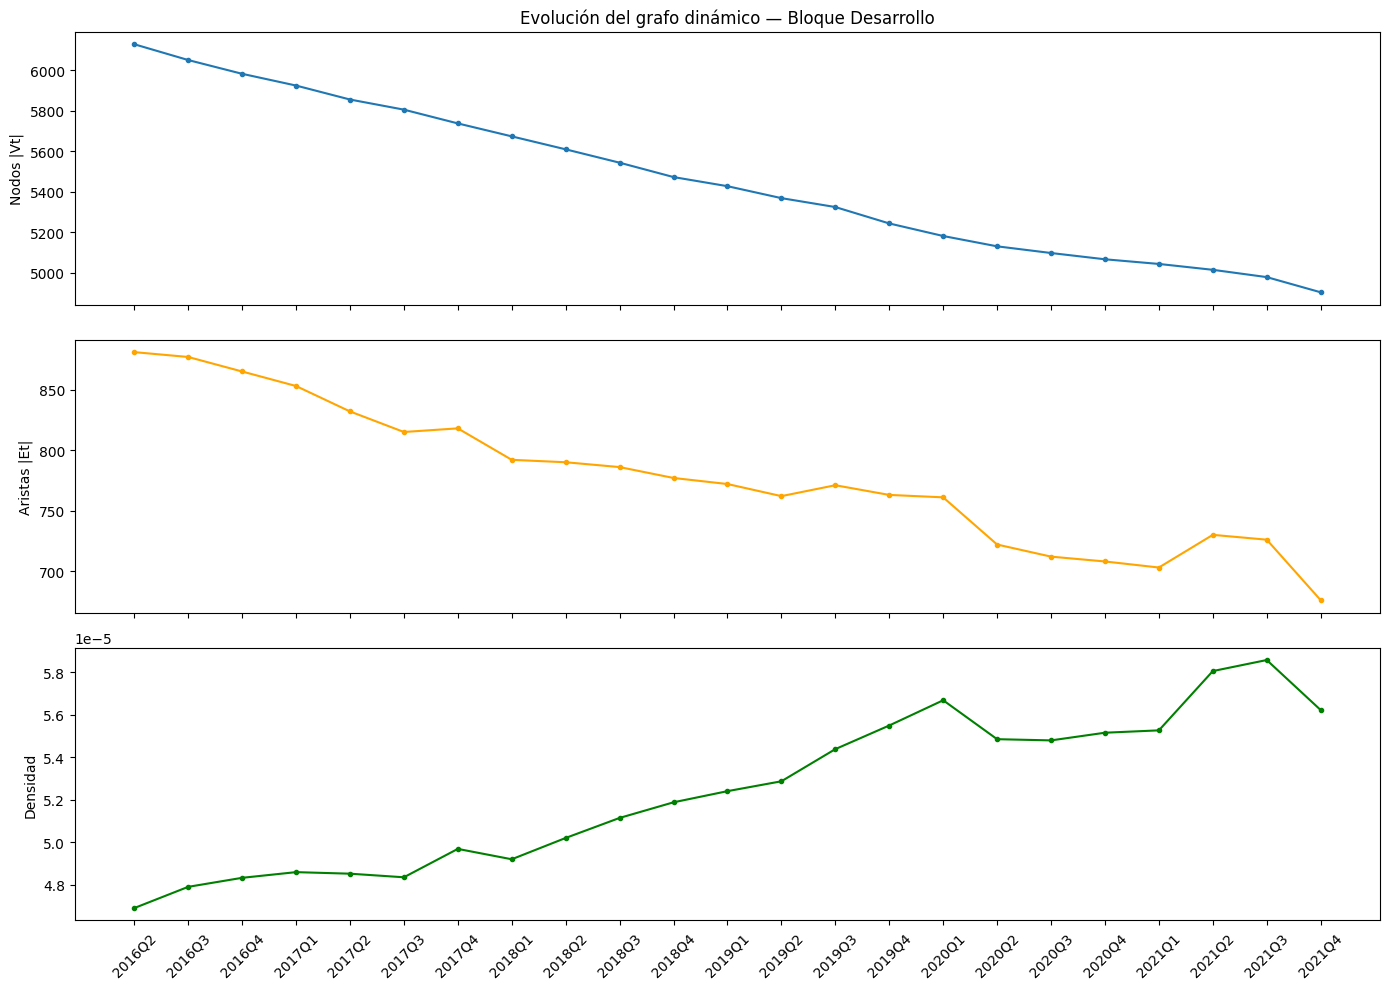


Densidad media   : 0.000052
Aristas media/t  : 778
Nodos media/t    : 5460
Positivos totales: 63


In [19]:
# ============================================================
# CELDA 5 — Análisis exploratorio del grafo dinámico
# ============================================================
import matplotlib.pyplot as plt

periodos    = [d.period for d in snapshots_dev]
n_nodos     = [d.num_nodes for d in snapshots_dev]
n_aristas   = [d.edge_index.shape[1] // 2 for d in snapshots_dev]
densidades  = [
    2 * e / (n * (n - 1)) if n > 1 else 0
    for e, n in zip(n_aristas, n_nodos)
]
n_positivos = [int(d.y.sum().item()) for d in snapshots_dev]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(periodos, n_nodos, marker='o', markersize=3)
axes[0].set_ylabel('Nodos |Vt|')
axes[0].set_title('Evolución del grafo dinámico — Bloque Desarrollo')

axes[1].plot(periodos, n_aristas, marker='o', markersize=3, color='orange')
axes[1].set_ylabel('Aristas |Et|')

axes[2].plot(periodos, densidades, marker='o', markersize=3, color='green')
axes[2].set_ylabel('Densidad')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(GRAPHS / 'grafo_evolucion_desarrollo.png', dpi=150)
plt.show()

print(f'\nDensidad media   : {np.mean(densidades):.6f}')
print(f'Aristas media/t  : {np.mean(n_aristas):.0f}')
print(f'Nodos media/t    : {np.mean(n_nodos):.0f}')
print(f'Positivos totales: {sum(n_positivos)}')

Evolución temporal — qué esperamos ver
El número de nodos decrece monótonamente porque el sector bancario se consolida: quiebras, fusiones y adquisiciones reducen el número de entidades activas de ~6.100 en 2016Q2 a ~4.900 en 2021Q4.
El número de aristas no tiene por qué decrecer monótonamente. Una fusión elimina un nodo pero puede aumentar el tamaño del holding del banco adquirente, aumentando las aristas del clique resultante. La relación entre nodos y aristas es no lineal y depende de la distribución de tamaños de holdings.
El desierto de positivos en 2021 (cero quiebras en los cuatro trimestres) es visible en el output de VSCode. Esto es relevante para el entrenamiento del T-GCN: hay trimestres sin señal supervisada positiva, lo que hace el problema aún más difícil y justifica la detección de anomalías no supervisada como componente principal.


Desarrollo — sanity check
63 positivos sobre 23 trimestres. Tu tabla de failures suma 70 observaciones en el bloque 2016Q2-2021Q4. La diferencia de 7 corresponde a 2016Q1 que fue omitido por no tener contexto previo — esos 7 positivos de 2016Q1 no tienen embedding y por tanto no aparecen en ningún snapshot. Esto es correcto y esperado, no es un error.
Densidad 5.2×10⁻⁵ confirma que el grafo es extremadamente disperso. Con ~778 aristas sobre un grafo de ~5.460 nodos, la media de bancos por holding que tiene al menos un compañero es pequeña. La mayoría de los ~5.460 nodos son independientes o únicos en su holding en cada trimestre.

In [20]:
# ============================================================
# CELDA 6 — Guardar snapshots desarrollo
# ============================================================
builder_dev.save_snapshots(snapshots_dev, GRAPHS / 'snapshots_desarrollo')
print('Snapshots desarrollo guardados ✓')

Snapshots guardados en D:\financial_risk_data\graphs\snapshots_desarrollo
Snapshots desarrollo guardados ✓


En este punto del pipeline tenemos los 23 snapshots de desarrollo $G_{dev}^t$ con 63 positivos  (la suma son 70 postivos que si contamos los 7 del primer trimestre no incluido nos dan el total de 107 positivos). La dimensión de los nodos es consistente en todos los snapshots $x_i^t\in\mathbb{R}^{204}$ y tenemos la division temporal verificada. En el siguietne notebook desarrollaremos el modelo de T-GCN junto con su entrenamiento.